
Final Learned Q-Table (Expected Future Rewards):
                Walk Left  Walk Right
0: Classroom        -3.61       -0.56
1: Corridor         -2.93        0.55
2: Strict Prof      -1.28        6.19
3: Corridor         -0.41        8.00
4: Corridor          4.49       10.00
5: Cafeteria         0.00        0.00


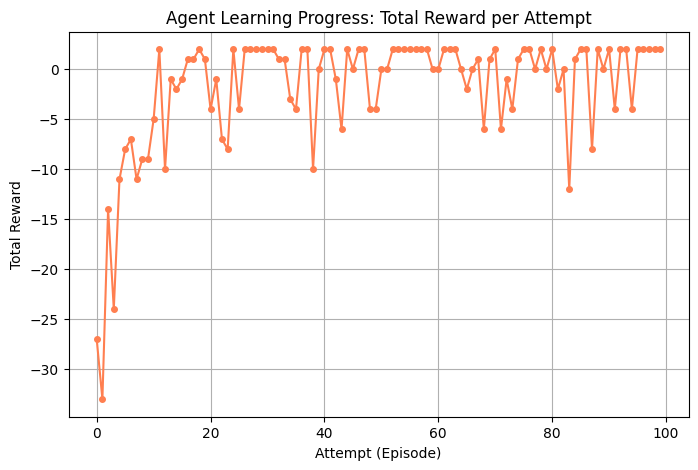

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

# 1. Define the Relatable Environment
# A 1D hallway with 6 locations.
locations = ['0: Classroom', '1: Corridor', '2: Strict Prof', '3: Corridor', '4: Corridor', '5: Cafeteria']
n_states = len(locations)
n_actions = 2
actions_names = ['Walk Left', 'Walk Right']
goal_state = 5

def step(state, action):
    # Transition logic: Can't walk left of 0 or right of 5
    if action == 0:  # Move Left
        next_state = max(0, state - 1)
    else:  # Move Right
        next_state = min(n_states - 1, state + 1)

    # Reward logic based on the scenario
    if next_state == goal_state:
        reward = 10  # Found the food!
        done = True
    elif next_state == 2:
        reward = -5  # Caught by the Strict Professor!
        done = False
    else:
        reward = -1  # Small penalty for wasting time/energy
        done = False

    return next_state, reward, done

# 2. Initialize Q-Table (Empty Cheat-Sheet)
q_table = np.zeros((n_states, n_actions))

# 3. Hyperparameters
alpha = 0.1  # Learning rate (How fast it overwrites old knowledge)
gamma = 0.9  # Discount factor (Importance of future rewards)
epsilon = 0.2  # Exploration rate (20% of the time, try a random action)
episodes = 100  # Give the agent 100 attempts to find the best path

# 4. Training Loop
rewards_per_episode = []

for episode in range(episodes):
    state = 0  # Always start in the Classroom
    total_reward = 0
    done = False

    while not done:
        # Epsilon-Greedy Action Selection
        if random.uniform(0, 1) < epsilon:
            action = random.choice([0, 1])  # Explore (Random choice)
        else:
            action = np.argmax(q_table[state])  # Exploit (Best known choice)

        next_state, reward, done = step(state, action)

        # The Core: Bellman Equation Update
        best_next_action = np.argmax(q_table[next_state])
        td_target = reward + gamma * q_table[next_state, best_next_action]
        td_error = td_target - q_table[state, action]

        q_table[state, action] += alpha * td_error

        state = next_state
        total_reward += reward

        # Prevent infinite loops in early exploration
        if total_reward < -50:
            break

    rewards_per_episode.append(total_reward)

# 5. Display the Interpretable Q-Table
print("\nFinal Learned Q-Table (Expected Future Rewards):")
q_df = pd.DataFrame(np.round(q_table, 2), index=locations, columns=actions_names)
print(q_df)

# 6. Visualization: Learning Curve
plt.figure(figsize=(8, 5))
plt.plot(rewards_per_episode, color='coral', marker='o', markersize=4)
plt.title('Agent Learning Progress: Total Reward per Attempt')
plt.xlabel('Attempt (Episode)')
plt.ylabel('Total Reward')
plt.grid(True)
plt.show()


Final Learned Q-Table (Expected Future Rewards):
                Walk Left  Walk Right
0: Classroom        -3.98       -0.55
1: Corridor         -2.95        0.55
2: Strict Prof      -1.67        6.19
3: Corridor         -1.44        8.00
4: Corridor          3.36       10.00
5: Cafeteria         0.00        0.00


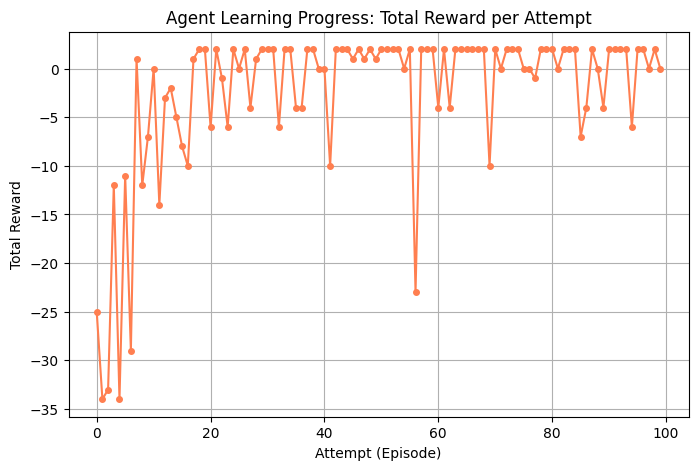


TASK 1: Optimal Action Sequence from Q-Table
  State 0: Classroom → Action: Walk Right
  State 1: Corridor → Action: Walk Right
  State 2: Strict Prof → Action: Walk Right
  State 3: Corridor → Action: Walk Right
  State 4: Corridor → Action: Walk Right
  State 5: Cafeteria → GOAL REACHED!

Summary: Agent walks RIGHT from Classroom all the way to Cafeteria.
Sequence: State 0 → 1 → 2 → 3 → 4 → 5 (passes through Strict Prof, still walks right)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

# 1. Environment
locations = ['0: Classroom', '1: Corridor', '2: Strict Prof', '3: Corridor', '4: Corridor', '5: Cafeteria']
n_states = len(locations)
n_actions = 2
actions_names = ['Walk Left', 'Walk Right']
goal_state = 5

def step(state, action):
    if action == 0:
        next_state = max(0, state - 1)
    else:
        next_state = min(n_states - 1, state + 1)

    if next_state == goal_state:
        reward = 10
        done = True
    elif next_state == 2:
        reward = -5
        done = False
    else:
        reward = -1
        done = False

    return next_state, reward, done

# 2. Q-Table
q_table = np.zeros((n_states, n_actions))

# 3. Hyperparameters
alpha = 0.1
gamma = 0.9
epsilon = 0.2
episodes = 100

# 4. Training
rewards_per_episode = []

for episode in range(episodes):
    state = 0
    total_reward = 0
    done = False

    while not done:
        if random.uniform(0, 1) < epsilon:
            action = random.choice([0, 1])
        else:
            action = np.argmax(q_table[state])

        next_state, reward, done = step(state, action)

        best_next_action = np.argmax(q_table[next_state])
        td_target = reward + gamma * q_table[next_state, best_next_action]
        td_error = td_target - q_table[state, action]
        q_table[state, action] += alpha * td_error

        state = next_state
        total_reward += reward

        if total_reward < -50:
            break

    rewards_per_episode.append(total_reward)

# 5. Q-Table display
print("\nFinal Learned Q-Table (Expected Future Rewards):")
q_df = pd.DataFrame(np.round(q_table, 2), index=locations, columns=actions_names)
print(q_df)

# 6. Learning curve
plt.figure(figsize=(8, 5))
plt.plot(rewards_per_episode, color='coral', marker='o', markersize=4)
plt.title('Agent Learning Progress: Total Reward per Attempt')
plt.xlabel('Attempt (Episode)')
plt.ylabel('Total Reward')
plt.grid(True)
plt.show()

# --- TASK 1 ANSWER ---
print("\n" + "="*50)
print("TASK 1: Optimal Action Sequence from Q-Table")
print("="*50)

state = 0
path = []
visited = set()

while state != goal_state and state not in visited:
    visited.add(state)
    action = np.argmax(q_table[state])
    action_name = actions_names[action]
    print(f"  State {locations[state]} → Action: {action_name}")
    path.append((locations[state], action_name))
    if action == 0:
        state = max(0, state - 1)
    else:
        state = min(n_states - 1, state + 1)

print(f"  State {locations[state]} → GOAL REACHED!")
print("\nSummary: Agent walks RIGHT from Classroom all the way to Cafeteria.")
print("Sequence: State 0 → 1 → 2 → 3 → 4 → 5 (passes through Strict Prof, still walks right)")


Short-Sighted Q-Table (gamma=0.1):
                Walk Left  Walk Right
0: Classroom        -1.11       -1.11
1: Corridor         -1.11       -5.09
2: Strict Prof      -1.02       -1.00
3: Corridor         -1.74       -0.15
4: Corridor         -0.35        9.53
5: Cafeteria         0.00        0.00


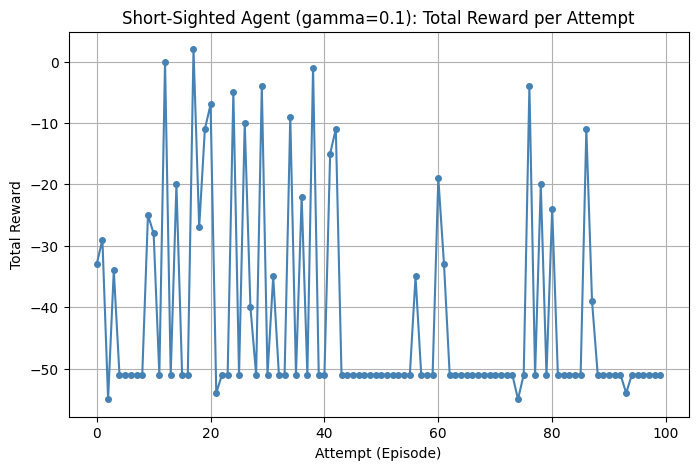


TASK 2: Mathematical Explanation — Short-Sighted Agent

With gamma=0.1, the Bellman update becomes:
  Q(s,a) += alpha * [ reward + 0.1 * max(Q(s',a')) - Q(s,a) ]

For State 1 choosing Walk Right → State 2 (Strict Prof):
  immediate reward = -5
  discounted future = 0.1 * Q(2, best_action) ≈ 0.1 * small_value ≈ ~0

  So Q(1, Right) ≈ -5  (heavily penalized, immediate pain dominates)

For State 1 choosing Walk Right with gamma=0.9:
  Future reward of reaching Cafeteria (+10) discounted less aggressively.
  Agent "sees" that enduring path through penalties leads to +10.
  Q values propagate reward signal further back through states.

With gamma=0.1:
  Future rewards shrink by 10x each step.
  Cafeteria reward at 4 steps away: 0.1^4 * 10 = 0.0001 ≈ negligible.
  Agent becomes myopic — only immediate reward matters.
  May walk INTO Strict Prof repeatedly (immediate -5 still "explored")
  or get stuck — cannot plan ahead toward Cafeteria (+10).

Conclusion: Low gamma = agent cannot value di

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

locations = ['0: Classroom', '1: Corridor', '2: Strict Prof', '3: Corridor', '4: Corridor', '5: Cafeteria']
n_states = len(locations)
n_actions = 2
actions_names = ['Walk Left', 'Walk Right']
goal_state = 5

def step(state, action):
    if action == 0:
        next_state = max(0, state - 1)
    else:
        next_state = min(n_states - 1, state + 1)

    if next_state == goal_state:
        reward = 10
        done = True
    elif next_state == 2:
        reward = -5
        done = False
    else:
        reward = -1
        done = False

    return next_state, reward, done

q_table_shortsighted = np.zeros((n_states, n_actions))

alpha = 0.1
gamma = 0.1
epsilon = 0.2
episodes = 100

rewards_per_episode = []

for episode in range(episodes):
    state = 0
    total_reward = 0
    done = False

    while not done:
        if random.uniform(0, 1) < epsilon:
            action = random.choice([0, 1])
        else:
            action = np.argmax(q_table_shortsighted[state])

        next_state, reward, done = step(state, action)

        best_next_action = np.argmax(q_table_shortsighted[next_state])
        td_target = reward + gamma * q_table_shortsighted[next_state, best_next_action]
        td_error = td_target - q_table_shortsighted[state, action]
        q_table_shortsighted[state, action] += alpha * td_error

        state = next_state
        total_reward += reward

        if total_reward < -50:
            break

    rewards_per_episode.append(total_reward)

print("\nShort-Sighted Q-Table (gamma=0.1):")
q_df2 = pd.DataFrame(np.round(q_table_shortsighted, 2), index=locations, columns=actions_names)
print(q_df2)

plt.figure(figsize=(8, 5))
plt.plot(rewards_per_episode, color='steelblue', marker='o', markersize=4)
plt.title('Short-Sighted Agent (gamma=0.1): Total Reward per Attempt')
plt.xlabel('Attempt (Episode)')
plt.ylabel('Total Reward')
plt.grid(True)
plt.show()

# --- TASK 2 ANSWER ---
print("\n" + "="*60)
print("TASK 2: Mathematical Explanation — Short-Sighted Agent")
print("="*60)
print("""
With gamma=0.1, the Bellman update becomes:
  Q(s,a) += alpha * [ reward + 0.1 * max(Q(s',a')) - Q(s,a) ]

For State 1 choosing Walk Right → State 2 (Strict Prof):
  immediate reward = -5
  discounted future = 0.1 * Q(2, best_action) ≈ 0.1 * small_value ≈ ~0

  So Q(1, Right) ≈ -5  (heavily penalized, immediate pain dominates)

For State 1 choosing Walk Right with gamma=0.9:
  Future reward of reaching Cafeteria (+10) discounted less aggressively.
  Agent "sees" that enduring path through penalties leads to +10.
  Q values propagate reward signal further back through states.

With gamma=0.1:
  Future rewards shrink by 10x each step.
  Cafeteria reward at 4 steps away: 0.1^4 * 10 = 0.0001 ≈ negligible.
  Agent becomes myopic — only immediate reward matters.
  May walk INTO Strict Prof repeatedly (immediate -5 still "explored")
  or get stuck — cannot plan ahead toward Cafeteria (+10).

Conclusion: Low gamma = agent cannot value distant goals.
High gamma (0.9) = agent willing to endure short-term pain for long-term gain.
""")

## Task 1
Optimal sequence from Q-Table (gamma=0.9):
State 0 → Walk Right → State 1 → Walk Right → State 2 → Walk Right
→ State 3 → Walk Right → State 4 → Walk Right → State 5 (Goal)
Agent walks RIGHT through all states including Strict Prof (State 2),
as future reward from Cafeteria outweighs the -5 penalty.

## Task 2
With gamma=0.1, Q(1, Walk Right) ≈ -5.09.
Bellman update: Q(1,Right) += 0.1 * [-5 + 0.1 * max(Q(2,·)) - Q(1,Right)]
Discounted future from State 2 onward ≈ 0.1^3 * 10 = 0.01 ≈ negligible.
Immediate -5 dominates → agent learns Walk Right from State 1 is BAD.
Agent becomes myopic, cannot plan 4 steps ahead to Cafeteria.
Graph shows near-random chaotic rewards — no stable policy learned.